In [ ]:
from google.colab import files
uploaded = files.upload()


Saving dataset.csv to dataset.csv
Saving Testing.csv to Testing.csv
Saving Training.csv to Training.csv


In [ ]:
!pip install pandas numpy scikit-learn

In [ ]:
import os

for file in os.listdir():
    print(file)

.config
dataset.csv
Training.csv
Testing.csv
sample_data


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving symptom_Description.csv to symptom_Description.csv
Saving symptom_precaution.csv to symptom_precaution.csv
Saving Symptom_severity.csv to Symptom_severity.csv


In [ ]:
import os

print("Files in current directory:")
for file in os.listdir():
    print(file)

Files in current directory:
.config
dataset.csv
symptom_precaution.csv
Symptom_severity.csv
symptom_Description.csv
Training.csv
Testing.csv
sample_data


In [ ]:
import pandas as pd
import numpy as np
import csv
import re
import random

from sklearn import preprocessing
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from difflib import get_close_matches

In [ ]:
training = pd.read_csv('Training.csv')
testing = pd.read_csv('Testing.csv')

print(training.shape)
print(testing.shape)

(4920, 133)
(41, 133)


In [13]:
training.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [24]:
from sklearn.preprocessing import LabelEncoder

X = training.drop('prognosis', axis=1)
y = training['prognosis']

le = LabelEncoder()
y = le.fit_transform(y)

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.shape)
print(training['prognosis'].nunique())

X shape: (4920, 132)
y shape: (4920,)
(4920, 132)
41


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42
)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 1.0


In [29]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

KNN Accuracy: 1.0


In [30]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

svm_acc = accuracy_score(y_test, svm_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 1.0


In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 1.0


In [32]:
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'SVM',
        'Random Forest'
    ],
    'Accuracy': [
        lr_acc,
        knn_acc,
        svm_acc,
        rf_acc
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression       1.0
1                  KNN       1.0
2                  SVM       1.0
3        Random Forest       1.0


In [ ]:
import re
import random
import pandas as pd
import numpy as np
import csv

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from difflib import get_close_matches

In [33]:
training = pd.read_csv('/content/Training.csv')
testing = pd.read_csv('/content/Testing.csv')

training.head()

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


In [34]:
X = training.drop('prognosis', axis=1)

y = training['prognosis']

le = LabelEncoder()

y = le.fit_transform(y)

In [35]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

model.fit(X, y)

print("Model Trained Successfully")

Model Trained Successfully


In [36]:
symptoms_dict = {
    symptom: idx
    for idx, symptom in enumerate(X.columns)
}

In [37]:
description_list = {}

with open('/content/symptom_Description.csv') as csv_file:
    reader = csv.reader(csv_file)

    for row in reader:
        description_list[row[0]] = row[1]

In [38]:
precautionDictionary = {}

with open('/content/symptom_precaution.csv') as csv_file:
    reader = csv.reader(csv_file)

    for row in reader:
        precautionDictionary[row[0]] = [
            row[1],
            row[2],
            row[3],
            row[4]
        ]

In [39]:
def extract_symptoms(text):

    symptoms_found = []

    text = text.lower()

    for symptom in X.columns:

        if symptom.replace("_"," ") in text:

            symptoms_found.append(symptom)

    return symptoms_found

In [40]:
def predict_disease(symptoms):

    input_vector = np.zeros(len(symptoms_dict))

    for symptom in symptoms:

        if symptom in symptoms_dict:

            input_vector[
                symptoms_dict[symptom]
            ] = 1

    prediction = model.predict(
        [input_vector]
    )[0]

    disease = le.inverse_transform(
        [prediction]
    )[0]

    return disease

In [41]:
def chatbot():

    print("===== HealthCare ChatBot =====")

    sentence = input(
        "Describe your symptoms: "
    )

    symptoms = extract_symptoms(
        sentence
    )

    if len(symptoms) == 0:

        print(
            "No valid symptoms detected."
        )

        return

    disease = predict_disease(
        symptoms
    )

    print("\nPredicted Disease:")
    print(disease)

    print("\nDescription:")

    print(
        description_list.get(
            disease,
            "No description available"
        )
    )

    print("\nPrecautions:")

    if disease in precautionDictionary:

        for p in precautionDictionary[disease]:

            print("-", p)

In [43]:
chatbot()

===== HealthCare ChatBot =====
Describe your symptoms: I have headache fever and vomiting

Predicted Disease:
Paralysis (brain hemorrhage)

Description:
Intracerebral hemorrhage (ICH) is when blood suddenly bursts into brain tissue, causing damage to your brain. Symptoms usually appear suddenly during ICH. They include headache, weakness, confusion, and paralysis, particularly on one side of your body.

Precautions:
- massage
- eat healthy
- exercise
- consult doctor


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [44]:
from sklearn.metrics import confusion_matrix

rf_pred = model.predict(X_test)

In [45]:
cm = confusion_matrix(y_test, rf_pred)

print(cm)

[[41  0  0 ...  0  0  0]
 [ 0 46  0 ...  0  0  0]
 [ 0  0 52 ...  0  0  0]
 ...
 [ 0  0  0 ... 49  0  0]
 [ 0  0  0 ...  0 47  0]
 [ 0  0  0 ...  0  0 49]]


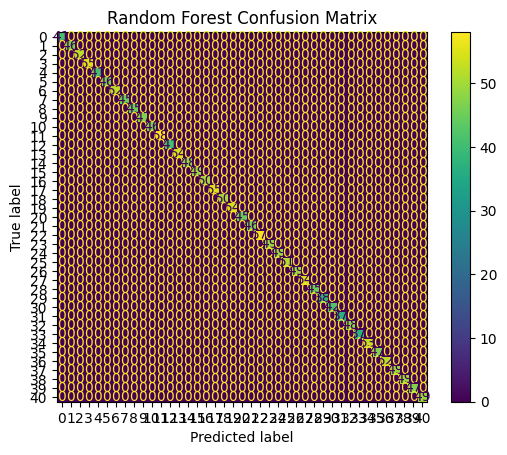

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest Confusion Matrix")
plt.show()

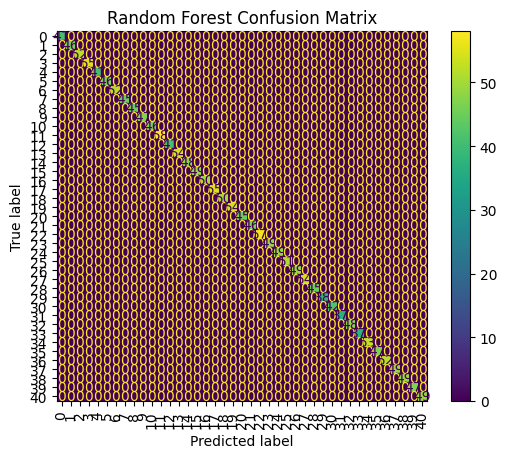

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    xticks_rotation='vertical'
)

plt.title("Random Forest Confusion Matrix")
plt.show()

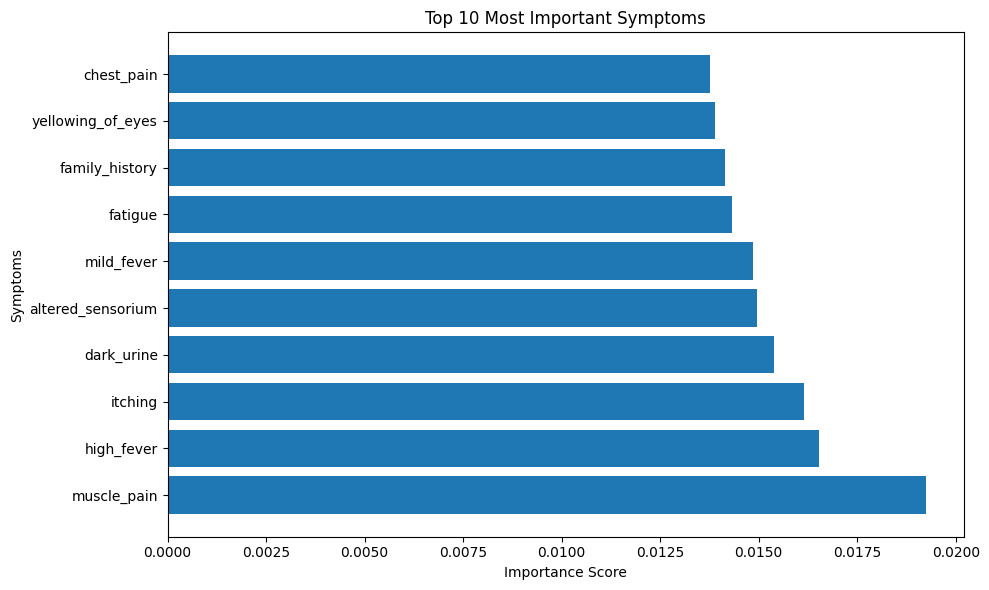

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importance = model.feature_importances_

# Create DataFrame
feature_importance = pd.DataFrame({
    'Symptom': X.columns,
    'Importance': importance
})

# Sort and take top 10
top10 = feature_importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(10,6))
plt.barh(top10['Symptom'], top10['Importance'])

plt.title('Top 10 Most Important Symptoms')
plt.xlabel('Importance Score')
plt.ylabel('Symptoms')

plt.tight_layout()
plt.show()